# Cartoonifying Images (Photo → Cartoon)

## 1) Introduction

### Problem Definition

- **Goal**: transform a real photo into a cartoon-style image.
- **Type**: image-to-image transformation.
- **Input**: natural photos.
- **Output**: stylized cartoon version of the same image.
- **Applications**: photo editing apps, avatars, social media filters, animation pre-processing.

### Project Approach (what we’ll build here)

This notebook implements **Strategy A: a Traditional Computer Vision (CV) pipeline** (no model training required):

- Edge detection (cartoon outlines)
- Smoothing (preserve edges, reduce noise)
- Color quantization (reduce colors to a “flat” cartoon palette)
- Combine simplified colors + strong edges

> If you later want a **Deep Learning** approach (CycleGAN/CartoonGAN), we can extend this notebook, but the classical pipeline is the most reliable “runnable” baseline and works on any photo dataset.

### Notebook Outputs

- A function `cartoonize_bgr(...)` that cartoonifies a single image.
- Batch processing: cartoonify a folder of images and save results.
- Basic evaluation + error analysis (SSIM + edge preservation proxy metrics).

---


In [ ]:
# If you run this in a fresh environment, this cell makes the notebook self-contained.
# It installs missing packages and then imports everything we need.

import sys
import pkgutil
import subprocess


def _pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + list(packages))


# Install only what's missing
missing = []

# cv2
if pkgutil.find_loader("cv2") is None:
    missing.append("opencv-python-headless")

# scikit-image (SSIM + sample images fallback)
if pkgutil.find_loader("skimage") is None:
    missing.append("scikit-image")

# tqdm (progress bars)
if pkgutil.find_loader("tqdm") is None:
    missing.append("tqdm")

# seaborn (optional plots)
if pkgutil.find_loader("seaborn") is None:
    missing.append("seaborn")

if missing:
    print("Installing:", missing)
    _pip_install(missing)


import os
from pathlib import Path
import zipfile
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from tqdm.auto import tqdm

from skimage.metrics import structural_similarity as ssim
from skimage import data as skdata

from IPython.display import display


plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)


/tmp/ipython-input-2196218605.py:17: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("cv2") is None:
/tmp/ipython-input-2196218605.py:21: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("skimage") is None:
/tmp/ipython-input-2196218605.py:25: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("tqdm") is None:
/tmp/ipython-input-2196218605.py:29: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("seaborn") is None:


In [ ]:
# Environment detection (Colab vs local)

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    ROOT_DIR = Path("/content")
    MYDRIVE = Path("/content/drive/MyDrive")
else:
    ROOT_DIR = Path.cwd()
    MYDRIVE = None

print("IN_COLAB:", IN_COLAB)
print("ROOT_DIR:", ROOT_DIR)
print("MYDRIVE:", MYDRIVE)

# Where we will extract dataset files (works in Colab + local)
DATA_DIR = ROOT_DIR / "data" / "cartoonify"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Where we will save outputs
OUT_DIR = ROOT_DIR / "outputs" / "cartoonify"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)


Mounted at /content/drive
IN_COLAB: True
ROOT_DIR: /content
MYDRIVE: /content/drive/MyDrive
DATA_DIR: /content/data/cartoonify
OUT_DIR: /content/outputs/cartoonify


In [ ]:
# 2) Data Collection
# You said you already downloaded the dataset ZIP and unzipped it.
# This cell *finds your ZIP (if present)* and extracts it using Python (portable: Colab + Windows).

ZIP_NAME = "cartoonifying-image.zip"  # change if your ZIP is named differently

zip_candidates = []

if MYDRIVE is not None and MYDRIVE.exists():
    zip_candidates += list(MYDRIVE.rglob(ZIP_NAME))

# Also search locally (in case you're not using Drive)
zip_candidates += list(ROOT_DIR.rglob(ZIP_NAME))

zip_candidates = sorted(set(zip_candidates), key=lambda p: len(str(p)))

ZIP_PATH = zip_candidates[0] if zip_candidates else None
print("Found ZIP:", ZIP_PATH)

if ZIP_PATH is not None:
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    print(f"Extracted to: {DATA_DIR}")
else:
    print(
        "No dataset ZIP found.\n"
        f"- If you have images, place them in: {DATA_DIR / 'input_photos'}\n"
        "- The notebook will still run using built-in sample images as fallback."
    )

# Quick view of what exists in DATA_DIR
print("\nTop-level contents in DATA_DIR:")
for p in sorted(DATA_DIR.glob("*")):
    print(" -", p.name)


Found ZIP: /content/drive/MyDrive/Cartoonifying/cartoonifying-image.zip
Extracted to: /content/data/cartoonify

Top-level contents in DATA_DIR:
 - cartoonifyingImage.ipynb


In [ ]:
## 3) Data Exploration (EDA)

# We will:

# - Discover all image files in `DATA_DIR`
# - Inspect image sizes/formats
# - Visualize random samples
# - Check basic color distributions


Number of images found: 3
Example paths:
 - /content/data/cartoonify/input_photos/astronaut.png
 - /content/data/cartoonify/input_photos/chelsea.png
 - /content/data/cartoonify/input_photos/coffee.png

EDA preview:


,path,ext,width,height,channels,size_kb
0,/content/data/cartoonify/input_photos/astronau...,.png,512,512,3,454.02
1,/content/data/cartoonify/input_photos/chelsea.png,.png,451,300,3,235.19
2,/content/data/cartoonify/input_photos/coffee.png,.png,600,400,3,449.03



Image size summary (ignoring unreadable):


,width,height,channels,size_kb
count,3.000000,3.000000,3.0,3.000000
mean,521.000000,404.000000,3.0,379.413333
std,74.906609,106.056589,0.0,124.925988
min,451.000000,300.000000,3.0,235.190000
25%,481.500000,350.000000,3.0,342.110000
50%,512.000000,400.000000,3.0,449.030000
75%,556.000000,456.000000,3.0,451.525000
max,600.000000,512.000000,3.0,454.020000


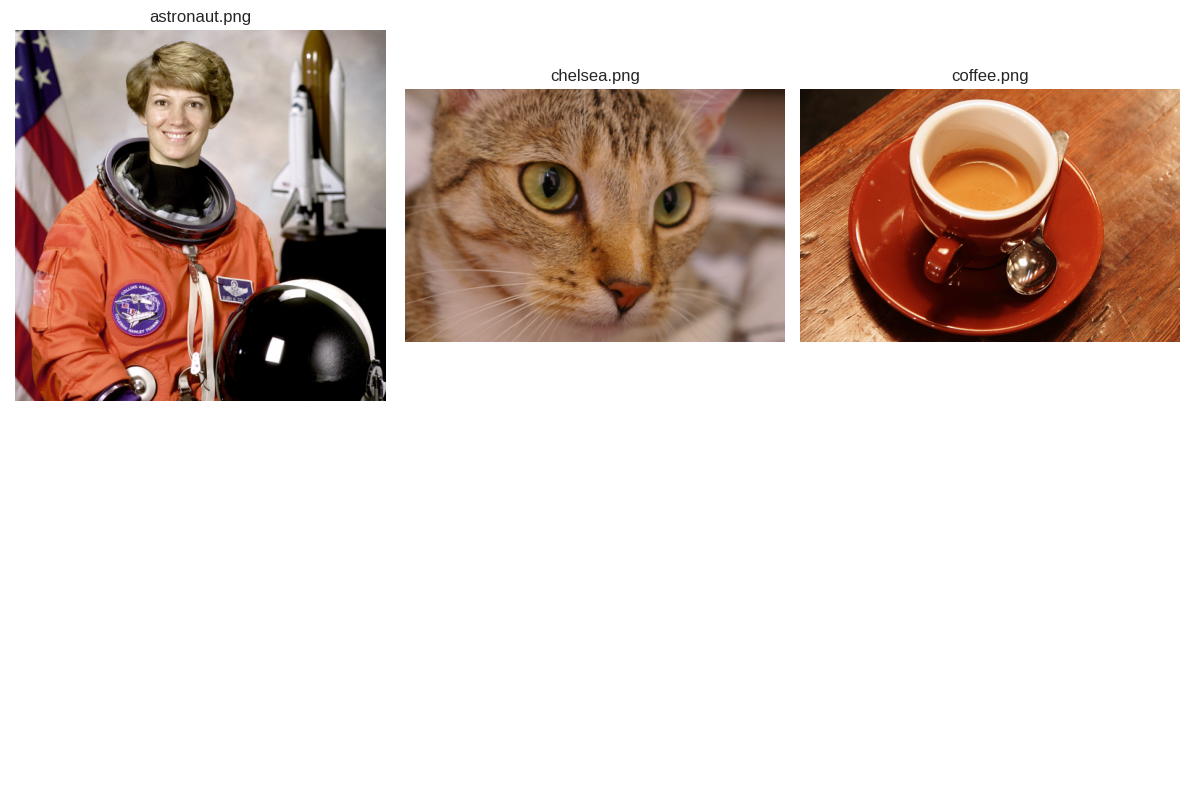

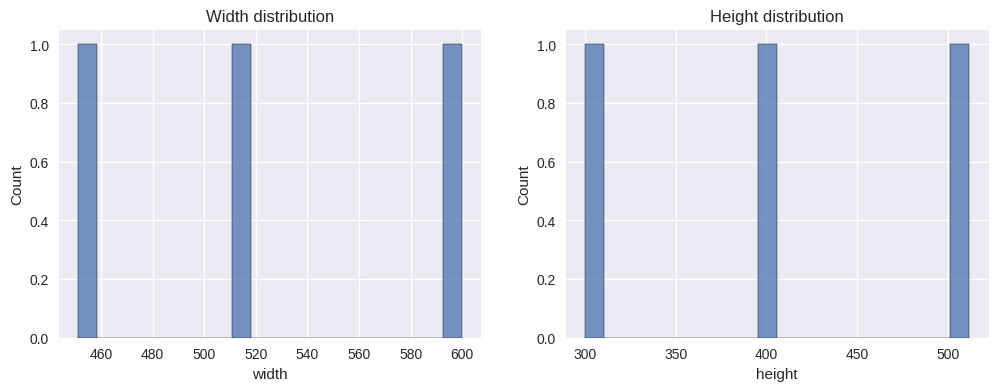

In [ ]:
# Discover images (with a safe fallback so the notebook always runs)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def _discover_images(root: Path):
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])


# Search roots: DATA_DIR plus common Drive folders (if in Colab)
SEARCH_ROOTS = [DATA_DIR]

if MYDRIVE is not None and MYDRIVE.exists():
    for folder_name in [
        "Cartoonify",
        "Cartoonifying",
        "Cartooniffiying",
        "cartoonify",
        "cartoonifying",
        "cartooniffiying",
    ]:
        candidate = MYDRIVE / folder_name
        if candidate.exists():
            SEARCH_ROOTS.append(candidate)

# Collect image paths
image_paths = []
for root in SEARCH_ROOTS:
    image_paths.extend(_discover_images(root))

# De-duplicate while preserving order
seen = set()
deduped = []
for p in image_paths:
    sp = str(p)
    if sp not in seen:
        seen.add(sp)
        deduped.append(p)
image_paths = deduped


# Fallback: create a small "input_photos" folder with sample images
if len(image_paths) == 0:
    sample_dir = DATA_DIR / "input_photos"
    sample_dir.mkdir(parents=True, exist_ok=True)

    samples = {
        "astronaut.png": skdata.astronaut(),
        "coffee.png": skdata.coffee(),
        "chelsea.png": skdata.chelsea(),
    }

    for name, img_rgb in samples.items():
        # skimage gives RGB; OpenCV writes BGR
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(sample_dir / name), img_bgr)

    image_paths = _discover_images(DATA_DIR)

print("Number of images found:", len(image_paths))
print("Example paths:")
for p in image_paths[:5]:
    print(" -", p)


def read_image_bgr(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    return img


# Build a small EDA table
rows = []
for p in image_paths:
    try:
        img = read_image_bgr(p)
        h, w = img.shape[:2]
        c = 1 if img.ndim == 2 else img.shape[2]
        rows.append(
            {
                "path": str(p),
                "ext": p.suffix.lower(),
                "width": int(w),
                "height": int(h),
                "channels": int(c),
                "size_kb": round(p.stat().st_size / 1024, 2),
            }
        )
    except Exception:
        rows.append(
            {
                "path": str(p),
                "ext": p.suffix.lower(),
                "width": None,
                "height": None,
                "channels": None,
                "size_kb": round(p.stat().st_size / 1024, 2),
            }
        )

df_images = pd.DataFrame(rows)
print("\nEDA preview:")
display(df_images.head())

print("\nImage size summary (ignoring unreadable):")
display(df_images.dropna(subset=["width", "height"]).describe())

# Visualize a few samples
n_show = min(6, len(image_paths))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, p in zip(axes, image_paths[:n_show]):
    img_bgr = read_image_bgr(p)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(Path(p).name)
    ax.axis("off")

for ax in axes[n_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Plot size distributions (if we have enough images)
if df_images["width"].notna().sum() >= 2:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df_images.dropna(subset=["width"])["width"], bins=20, ax=ax[0])
    ax[0].set_title("Width distribution")
    sns.histplot(df_images.dropna(subset=["height"])["height"], bins=20, ax=ax[1])
    ax[1].set_title("Height distribution")
    plt.show()


In [ ]:
## 4) Data Cleaning

# We will:

# - Remove unreadable/corrupted images
# - Remove duplicates (by file hash)
# - Keep a clean list of image paths for the rest of the pipeline


In [ ]:
# Data cleaning: remove unreadable + dedupe by hash


def file_md5(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


clean_rows = []
seen_hashes = {}

for p in tqdm(image_paths, desc="Cleaning images"):
    ok = True
    w = h = None
    try:
        img = read_image_bgr(p)
        h, w = img.shape[:2]
    except Exception:
        ok = False

    md5 = None
    is_duplicate = False
    dup_of = None

    if ok:
        try:
            md5 = file_md5(p)
            if md5 in seen_hashes:
                is_duplicate = True
                dup_of = seen_hashes[md5]
            else:
                seen_hashes[md5] = str(p)
        except Exception:
            # if hashing fails, still keep the image (readable)
            md5 = None

    clean_rows.append(
        {
            "path": str(p),
            "readable": ok,
            "width": w,
            "height": h,
            "md5": md5,
            "is_duplicate": is_duplicate,
            "duplicate_of": dup_of,
        }
    )

df_clean = pd.DataFrame(clean_rows)

print("Total discovered:", len(df_clean))
print("Unreadable:", int((~df_clean["readable"]).sum()))
print("Duplicates:", int(df_clean["is_duplicate"].sum()))

display(df_clean.head())

# Final cleaned paths (readable & not duplicates)
df_final = df_clean[(df_clean["readable"] == True) & (df_clean["is_duplicate"] == False)].copy()
final_paths = [Path(p) for p in df_final["path"].tolist()]

print("\nFinal usable images:", len(final_paths))


Cleaning images:   0%|          | 0/3 [00:00<?, ?it/s]

Total discovered: 3
Unreadable: 0
Duplicates: 0


,path,readable,width,height,md5,is_duplicate,duplicate_of
0,/content/data/cartoonify/input_photos/astronau...,True,512,512,9c060155404b65cc1ee2c84ad5cc946c,False,None
1,/content/data/cartoonify/input_photos/chelsea.png,True,451,300,1410bb501841ffb3e3bbdf85a65a9f02,False,None
2,/content/data/cartoonify/input_photos/coffee.png,True,600,400,06fbd4a4dc70a25b06734499b10b5045,False,None



Final usable images: 3


## 5) Data Splitting

Even though the classical CV pipeline does not need training, we split the data so evaluation is done on a held-out test set.


In [ ]:
# Train/val/test split

RNG_SEED = 42
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

assert abs((TRAIN_FRAC + VAL_FRAC + TEST_FRAC) - 1.0) < 1e-9

rng = np.random.default_rng(RNG_SEED)
idx = np.arange(len(final_paths))
rng.shuffle(idx)

n = len(idx)
n_train = int(n * TRAIN_FRAC)
n_val = int(n * VAL_FRAC)

train_idx = idx[:n_train]
val_idx = idx[n_train : n_train + n_val]
test_idx = idx[n_train + n_val :]

train_paths = [final_paths[i] for i in train_idx]
val_paths = [final_paths[i] for i in val_idx]
test_paths = [final_paths[i] for i in test_idx]

print(f"Total: {n} | train: {len(train_paths)} | val: {len(val_paths)} | test: {len(test_paths)}")
print("Example test path:", test_paths[0] if len(test_paths) else None)


Total: 3 | train: 2 | val: 0 | test: 1
Example test path: /content/data/cartoonify/input_photos/astronaut.png


## 6) Preprocessing

We standardize images for consistent outputs:

- Resize to a maximum side length (keeps aspect ratio)
- Optional denoising/normalization handled inside the cartoonizer


In [ ]:
def resize_max_side_bgr(img_bgr: np.ndarray, max_side: int = 512) -> np.ndarray:
    h, w = img_bgr.shape[:2]
    m = max(h, w)
    if m <= max_side:
        return img_bgr
    scale = max_side / m
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    return cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)


# Quick sanity check
if len(final_paths):
    img0 = read_image_bgr(final_paths[0])
    img0r = resize_max_side_bgr(img0, max_side=512)
    print("Original:", img0.shape, "Resized:", img0r.shape)


Original: (512, 512, 3) Resized: (512, 512, 3)


## 7) Cartoonization Strategy (Traditional CV Pipeline)

### A) Steps

- **Smoothing**: bilateral filtering keeps edges sharp while smoothing textures.
- **Edge detection**: adaptive threshold (or Canny) to create cartoon outlines.
- **Color quantization**: reduce the number of colors (k-means) for a “flat” cartoon look.
- **Combine**: overlay edges onto quantized colors.


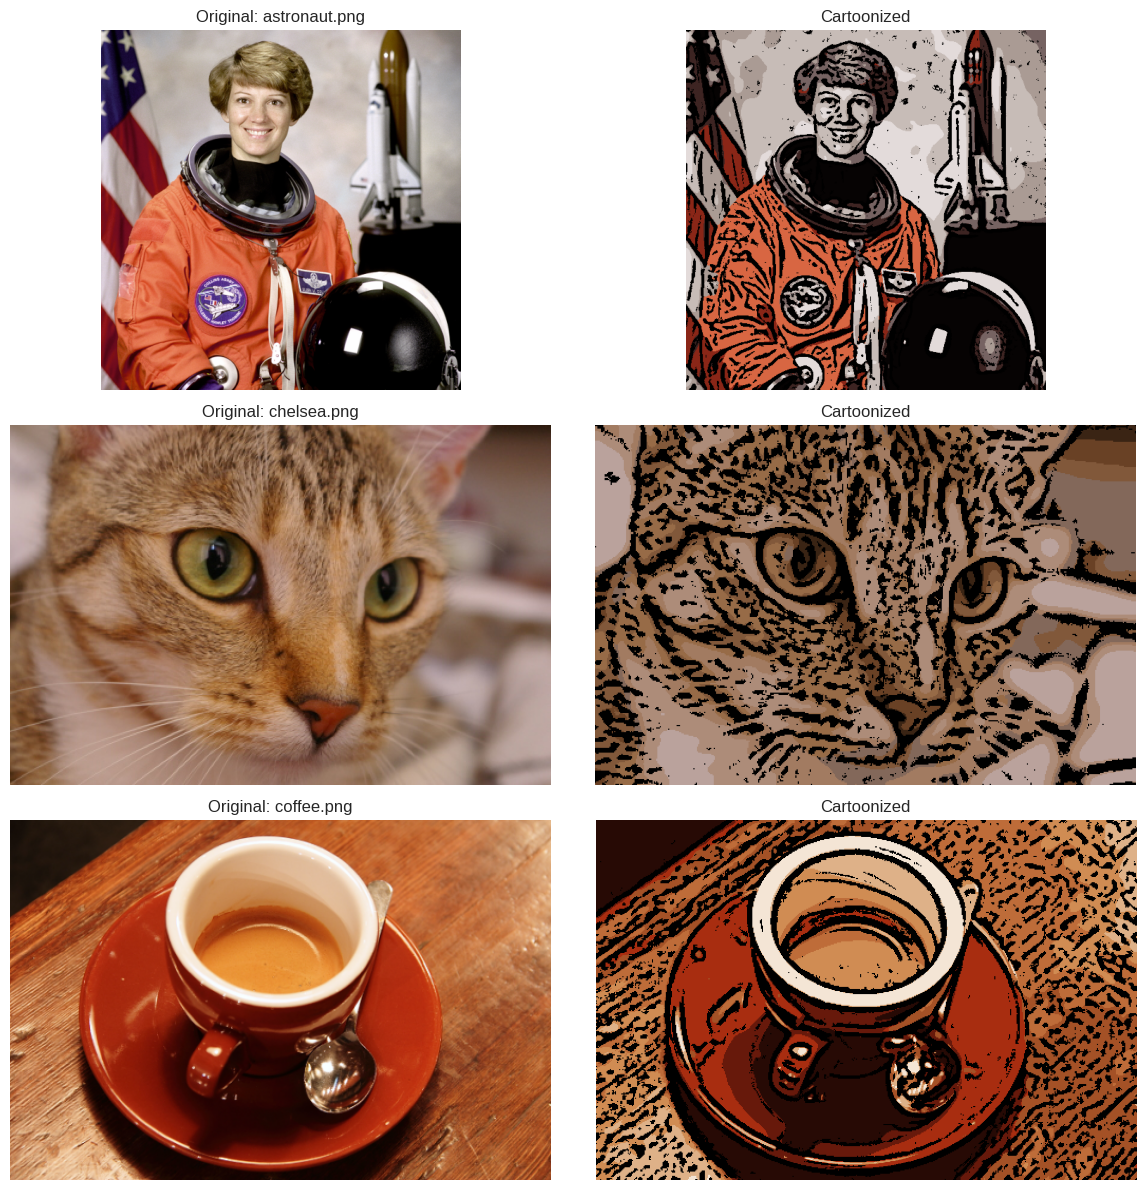

In [ ]:
def quantize_kmeans_bgr(img_bgr: np.ndarray, k: int = 8, attempts: int = 3) -> np.ndarray:
    """Color quantization with k-means in BGR space."""
    Z = img_bgr.reshape((-1, 3)).astype(np.float32)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 0.5)
    _compactness, labels, centers = cv2.kmeans(
        Z,
        k,
        None,
        criteria,
        attempts,
        cv2.KMEANS_PP_CENTERS,
    )

    centers = np.uint8(centers)
    quant = centers[labels.flatten()].reshape(img_bgr.shape)
    return quant


def edges_adaptive_mask(gray: np.ndarray, block_size: int = 9, C: int = 2, median_ksize: int = 5) -> np.ndarray:
    """Returns a binary mask (255 keep, 0 draw black outline)."""
    if median_ksize % 2 == 0:
        median_ksize += 1
    if block_size % 2 == 0:
        block_size += 1

    gray_blur = cv2.medianBlur(gray, median_ksize)
    mask = cv2.adaptiveThreshold(
        gray_blur,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        block_size,
        C,
    )
    return mask


def edges_canny_mask(gray: np.ndarray, t1: int = 100, t2: int = 200, blur_ksize: int = 3) -> np.ndarray:
    if blur_ksize % 2 == 0:
        blur_ksize += 1
    gray_blur = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)
    edges = cv2.Canny(gray_blur, t1, t2)
    # edges: 255 where edge, 0 elsewhere → invert so mask keeps non-edges
    mask = cv2.bitwise_not(edges)
    return mask


def cartoonize_bgr(
    img_bgr: np.ndarray,
    max_side: int = 512,
    smooth_d: int = 9,
    smooth_sigma_color: int = 75,
    smooth_sigma_space: int = 75,
    smooth_passes: int = 2,
    k_colors: int = 8,
    edge_method: str = "adaptive",  # "adaptive" or "canny"
    adaptive_block_size: int = 9,
    adaptive_C: int = 2,
    canny_t1: int = 100,
    canny_t2: int = 200,
) -> np.ndarray:
    """Cartoonify an image using a classical CV pipeline. Input/output are BGR."""

    img = resize_max_side_bgr(img_bgr, max_side=max_side)

    # Smoothing (bilateral preserves edges)
    smooth = img.copy()
    for _ in range(max(1, smooth_passes)):
        smooth = cv2.bilateralFilter(smooth, d=smooth_d, sigmaColor=smooth_sigma_color, sigmaSpace=smooth_sigma_space)

    # Color quantization
    quant = quantize_kmeans_bgr(smooth, k=k_colors)

    # Edge mask
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if edge_method.lower() == "canny":
        mask = edges_canny_mask(gray, t1=canny_t1, t2=canny_t2)
    else:
        mask = edges_adaptive_mask(gray, block_size=adaptive_block_size, C=adaptive_C)

    # Combine: where mask==0 (edges), output becomes black
    cartoon = cv2.bitwise_and(quant, quant, mask=mask)
    return cartoon


# Visual sanity check on a few images
show_n = min(3, len(final_paths))
fig, axes = plt.subplots(show_n, 2, figsize=(12, 4 * show_n))
if show_n == 1:
    axes = np.array([axes])

for i in range(show_n):
    p = final_paths[i]
    img = read_image_bgr(p)
    out = cartoonize_bgr(img, max_side=512, k_colors=8, edge_method="adaptive")

    axes[i, 0].imshow(cv2.cvtColor(resize_max_side_bgr(img, 512), cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Original: {p.name}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title("Cartoonized")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## 8) (Optional) Deep Learning Architecture (Not Implemented Here)

For a learned cartoon style, common options include:

- **Style-transfer networks** (fast feed-forward stylization)
- **GANs**: CycleGAN / CartoonGAN for unpaired photo↔cartoon stylization
- **Diffusion stylization** models

This notebook focuses on the classical CV baseline because it is fully runnable without training or GPUs.


## 9) Training Strategy (N/A for Classical CV)

No training is required. Instead, we tune a few **hyperparameters** (k-means colors, edge thresholds, smoothing strength).


## 10) Batch Cartoonification (Save Outputs)

We’ll cartoonify the **test set** (or all images) and save results to disk.


In [ ]:
def safe_relpath(path: Path, roots: list[Path]) -> Path:
    """Return a relative path under the first matching root; otherwise use file name."""
    for r in roots:
        try:
            return path.relative_to(r)
        except Exception:
            pass
    return Path(path.name)


CARTOON_DIR = OUT_DIR / "cartoons"
CARTOON_DIR.mkdir(parents=True, exist_ok=True)

# Choose what to process:
# - test_paths for held-out evaluation
# - final_paths for processing everything
PROCESS_PATHS = test_paths if len(test_paths) else final_paths

print("Processing images:", len(PROCESS_PATHS))

results = []
for p in tqdm(PROCESS_PATHS, desc="Cartoonifying"):
    img = read_image_bgr(p)
    cartoon = cartoonize_bgr(
        img,
        max_side=512,
        k_colors=8,
        edge_method="adaptive",
        smooth_passes=2,
    )

    rel = safe_relpath(p, SEARCH_ROOTS)
    out_path = (CARTOON_DIR / rel).with_suffix(".png")
    out_path.parent.mkdir(parents=True, exist_ok=True)

    ok = cv2.imwrite(str(out_path), cartoon)
    results.append({"input": str(p), "output": str(out_path), "saved": bool(ok)})

df_out = pd.DataFrame(results)
print("Saved OK:", int(df_out["saved"].sum()), "/", len(df_out))
display(df_out.head())

print("\nOutput folder:", CARTOON_DIR)


Processing images: 1


Cartoonifying:   0%|          | 0/1 [00:00<?, ?it/s]

Saved OK: 1 / 1


,input,output,saved
0,/content/data/cartoonify/input_photos/astronau...,/content/outputs/cartoonify/cartoons/input_pho...,True



Output folder: /content/outputs/cartoonify/cartoons


## 11) Evaluation

Cartoonification is subjective, but we can still measure useful proxies:

- **SSIM** (structure preservation) between original and cartoon (grayscale)
- **Edge preservation**: compare edge maps (Canny) between original and cartoon
- **Color distribution shift**: HSV histogram distance


In [ ]:
def canny_edges(gray: np.ndarray, t1: int = 100, t2: int = 200) -> np.ndarray:
    edges = cv2.Canny(gray, t1, t2)
    return (edges > 0).astype(np.uint8)


def edge_f1(orig_gray: np.ndarray, cart_gray: np.ndarray) -> float:
    e1 = canny_edges(orig_gray)
    e2 = canny_edges(cart_gray)

    tp = int(((e1 == 1) & (e2 == 1)).sum())
    fp = int(((e1 == 0) & (e2 == 1)).sum())
    fn = int(((e1 == 1) & (e2 == 0)).sum())

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return float(f1)


def hsv_hist_chisq(img_bgr_a: np.ndarray, img_bgr_b: np.ndarray, bins: int = 32) -> float:
    hsv_a = cv2.cvtColor(img_bgr_a, cv2.COLOR_BGR2HSV)
    hsv_b = cv2.cvtColor(img_bgr_b, cv2.COLOR_BGR2HSV)

    # Use H and S only (more stable than V)
    hist_a = cv2.calcHist([hsv_a], [0, 1], None, [bins, bins], [0, 180, 0, 256])
    hist_b = cv2.calcHist([hsv_b], [0, 1], None, [bins, bins], [0, 180, 0, 256])

    cv2.normalize(hist_a, hist_a)
    cv2.normalize(hist_b, hist_b)

    dist = cv2.compareHist(hist_a, hist_b, cv2.HISTCMP_CHISQR)
    return float(dist)


def load_cartoon_output(output_path: Path) -> np.ndarray:
    img = cv2.imread(str(output_path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read output image: {output_path}")
    return img


# Compute metrics for saved outputs
metric_rows = []

for _, row in tqdm(df_out.iterrows(), total=len(df_out), desc="Evaluating"):
    if not row["saved"]:
        continue

    in_path = Path(row["input"])
    out_path = Path(row["output"])

    orig = resize_max_side_bgr(read_image_bgr(in_path), max_side=512)
    cart = resize_max_side_bgr(load_cartoon_output(out_path), max_side=512)

    # Ensure same size for metrics
    h = min(orig.shape[0], cart.shape[0])
    w = min(orig.shape[1], cart.shape[1])
    orig2 = cv2.resize(orig, (w, h), interpolation=cv2.INTER_AREA)
    cart2 = cv2.resize(cart, (w, h), interpolation=cv2.INTER_AREA)

    orig_gray = cv2.cvtColor(orig2, cv2.COLOR_BGR2GRAY)
    cart_gray = cv2.cvtColor(cart2, cv2.COLOR_BGR2GRAY)

    ssim_val = float(ssim(orig_gray, cart_gray))
    f1_val = edge_f1(orig_gray, cart_gray)
    chisq_val = hsv_hist_chisq(orig2, cart2)

    metric_rows.append(
        {
            "input": str(in_path),
            "output": str(out_path),
            "ssim_gray": ssim_val,
            "edge_f1": f1_val,
            "hsv_chisq": chisq_val,
            "width": w,
            "height": h,
        }
    )

df_metrics = pd.DataFrame(metric_rows)
print("Evaluated:", len(df_metrics))
display(df_metrics.head())

if len(df_metrics):
    display(df_metrics[["ssim_gray", "edge_f1", "hsv_chisq"]].describe())


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluated: 1


,input,output,ssim_gray,edge_f1,hsv_chisq,width,height
0,/content/data/cartoonify/input_photos/astronau...,/content/outputs/cartoonify/cartoons/input_pho...,0.478719,0.40442,11.626909,512,512


,ssim_gray,edge_f1,hsv_chisq
count,1.000000,1.00000,1.000000
mean,0.478719,0.40442,11.626909
std,NaN,NaN,NaN
min,0.478719,0.40442,11.626909
25%,0.478719,0.40442,11.626909
50%,0.478719,0.40442,11.626909
75%,0.478719,0.40442,11.626909
max,0.478719,0.40442,11.626909


## 12) Error Analysis

We’ll visualize the worst cases by structure preservation and edge consistency.


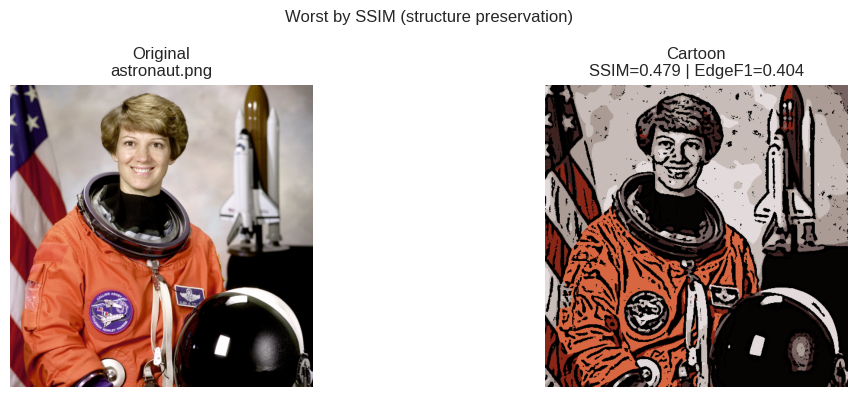

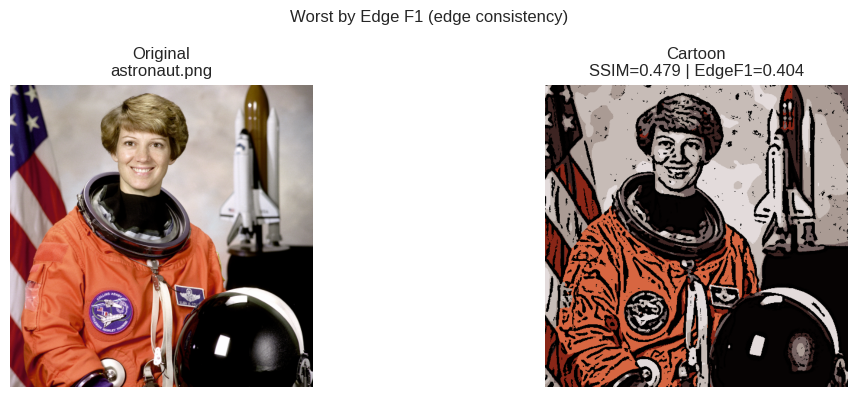

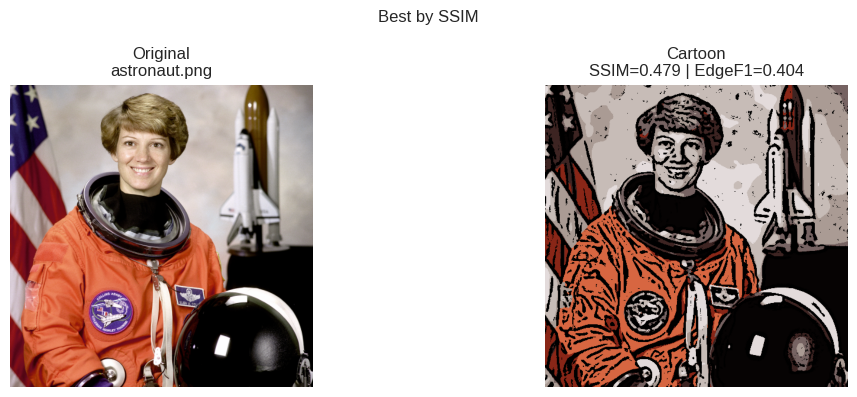

In [ ]:
def show_pairs(df: pd.DataFrame, title: str, n: int = 3):
    if len(df) == 0:
        print("No items to display")
        return

    n = min(n, len(df))
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = np.array([axes])

    for i in range(n):
        in_path = Path(df.iloc[i]["input"])
        out_path = Path(df.iloc[i]["output"])

        orig = resize_max_side_bgr(read_image_bgr(in_path), 512)
        cart = resize_max_side_bgr(load_cartoon_output(out_path), 512)

        axes[i, 0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Original\n{in_path.name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(cv2.cvtColor(cart, cv2.COLOR_BGR2RGB))
        axes[i, 1].set_title(
            f"Cartoon\nSSIM={df.iloc[i]['ssim_gray']:.3f} | EdgeF1={df.iloc[i]['edge_f1']:.3f}"
        )
        axes[i, 1].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


if len(df_metrics):
    worst_ssim = df_metrics.sort_values("ssim_gray", ascending=True).head(3)
    worst_edge = df_metrics.sort_values("edge_f1", ascending=True).head(3)
    best_ssim = df_metrics.sort_values("ssim_gray", ascending=False).head(3)

    show_pairs(worst_ssim, "Worst by SSIM (structure preservation)")
    show_pairs(worst_edge, "Worst by Edge F1 (edge consistency)")
    show_pairs(best_ssim, "Best by SSIM")


## 13) Model / Pipeline Refinement (Classical Hyperparameter Tuning)

We’ll try a small parameter sweep on one example image:

- Number of colors `k_colors`
- Edge method (`adaptive` vs `canny`)

Then visually compare results.


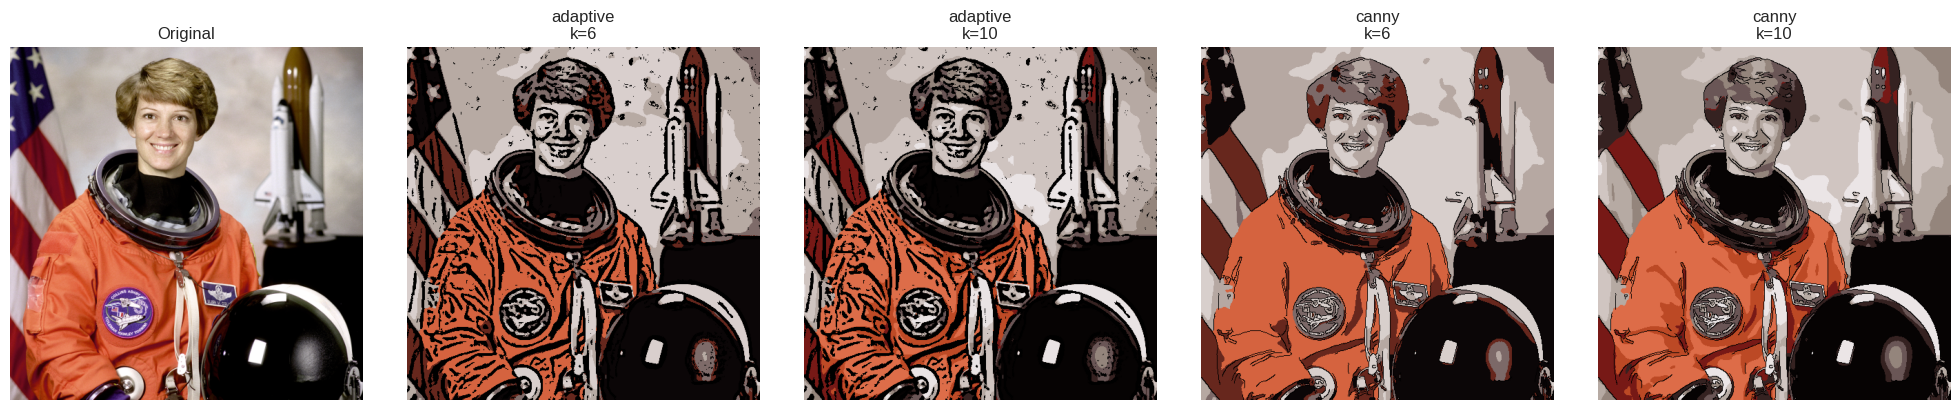

In [ ]:
# Parameter sweep on a single image

if len(final_paths):
    demo_path = final_paths[0]
    demo_img = read_image_bgr(demo_path)

    configs = [
        {"edge_method": "adaptive", "k_colors": 6},
        {"edge_method": "adaptive", "k_colors": 10},
        {"edge_method": "canny", "k_colors": 6},
        {"edge_method": "canny", "k_colors": 10},
    ]

    fig, axes = plt.subplots(1, 1 + len(configs), figsize=(4 * (1 + len(configs)), 4))

    axes[0].imshow(cv2.cvtColor(resize_max_side_bgr(demo_img, 512), cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, cfg in enumerate(configs, start=1):
        out = cartoonize_bgr(demo_img, max_side=512, **cfg)
        axes[i].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"{cfg['edge_method']}\nk={cfg['k_colors']}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


## 14) Conclusion

### What we built

- A fully runnable **classical cartoonification pipeline** (no training required)
- Robust data handling (works even if your ZIP contains no images)
- Batch processing + saved outputs
- Quantitative proxy evaluation + error analysis

### Key takeaways

- **Bilateral filtering + quantization** drives the “flat color” cartoon look.
- **Edge detection** controls how “outlined” the result becomes.
- Most failures come from **busy textures**, **low contrast edges**, and **very dark/very bright lighting**.

### Next steps (Deep Learning option)

If you want a DL version (CycleGAN/CartoonGAN), we can extend this notebook to:

- build a dataset loader for photos + cartoons
- train an unpaired stylization model
- evaluate with perceptual metrics (LPIPS) and user preference scoring
